---
<a id='week5'></a>
# Week 5 — Scenario Analysis *(Optional — Complete Only if Time Permits)*

> ⚠️ **Proceed only if Weeks 3 and 4 are fully complete, documented, and committed to GitHub.** If time is limited, skip to Week 6.

**Learning Objective:** Build a what-if scenario module to simulate emissions policy impact.


### Setup — Reload Data

This notebook runs independently of Weeks 3–4. Reload the filtered actuals (grey historical reference line, §5.3) and the ETS(A,Ad,N) BAU forecasts exported from Week 4 (basis for §5.2's scenario calculation).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from constants import *

df_filtered = pd.read_csv('../data/ghg_filtered.csv')
ets_forecasts = pd.read_csv('../data/ets_forecasts.csv')


<a id='51-design'></a>
### 5.1 Scenario Design

| Scenario | Label | Applied from 2025 |
|----------|-------|-------------------|
| A | Business as Usual (BAU) | ETS(A,Ad,N) forecast unchanged |
| B | Moderate Mitigation | −2% per year applied to BAU |
| C | Aggressive Mitigation | −5% per year applied to BAU |

**✏️ Basis and limitations:**

**Business as Usual (BAU)** is *not* "emissions stay flat" — it is the ETS(A,Ad,N) damped-trend forecast from Week 4 taken as-is. That forecast already embeds each country's own historical trajectory, including any structural decline already underway (e.g. the UK's post-Climate-Change-Act decline, Germany's plateau). So "no policy change" here specifically means "no *additional* intervention beyond what's already baked into the fitted trend" — a scenario where China's trend keeps decelerating and the UK keeps declining is still BAU, because those are properties of the historical data, not the scenario logic.

**Moderate Mitigation (−2%/year)** and **Aggressive Mitigation (−5%/year)** are flat, uniform compounding reduction rates applied identically to all 10 countries. They are illustrative bounding cases, not derived from any underlying causal model — there is no link to GDP growth, energy-mix transition, carbon pricing, or technology deployment cost curves. Applying one percentage uniformly ignores enormous real-world heterogeneity: a −2%/year path is a modest ask for a country already decarbonizing its grid (e.g. Germany), but would require an unprecedented policy shift for a coal-dependent, still-industrializing economy (e.g. South Africa or India). The −5%/year Aggressive case is roughly the order of magnitude of the UK's actual historical decline rate discussed in Week 4's §4.4 trend interpretation — useful as a real-world sanity check on scale, but sustaining it for 16 consecutive years across all 10 countries simultaneously assumes uninterrupted policy commitment, no economic shocks or rebounds (the 2020 COVID dip-and-rebound visible throughout Weeks 3–4 is a reminder that real trajectories are rarely this smooth), and technology deployment at a pace historically achieved by only a handful of economies for short windows.

**Overall limitation:** these three scenarios are best read as *comparative, bounding cases* — a floor (BAU), a middle path, and an aggressive-but-plausible-scale path — rather than calibrated forecasts of what any specific country's policy trajectory will actually look like.

<a id='52-calc'></a>
### 5.2 Scenario Calculation

Compute annual projections from 2025 to 2040 for each country and scenario.

```python
# Outline — implement the details
# bau_2025_2040 = ETS(A,Ad,N) forecast values for 2025–2040 (from §4.3 fc_df)
# years_elapsed = np.arange(len(bau_2025_2040))  # 0, 1, 2, ...
# moderate   = bau_2025_2040 * (1 - 0.02) ** years_elapsed
# aggressive = bau_2025_2040 * (1 - 0.05) ** years_elapsed
```

Store in a tidy long-format DataFrame: `country, year, scenario, co2_projected`.
Save as `data/scenario_projections.csv`.

In [2]:
# Compute BAU, Moderate, Aggressive scenarios for all 10 countries
def bau_series(country, start, end):
    """BAU forecast (ETS mean) for `country`, sliced to years [start, end]."""
    return (
        ets_forecasts[ets_forecasts['country'] == country]
        .set_index('year')['mean']
        .sort_index()
        .loc[start:end]
    )

REDUCTION_RATES = {'BAU': 0.0, 'Moderate': 0.02, 'Aggressive': 0.05}
SCENARIO_YEARS = np.arange(2025, 2041)

scenario_rows = []
for country in COUNTRIES:
    bau_2025_2040 = bau_series(country, 2025, 2040)
    years_elapsed = np.arange(len(bau_2025_2040))
    for scenario, rate in REDUCTION_RATES.items():
        projected = bau_2025_2040.values * (1 - rate) ** years_elapsed
        for yr, val in zip(SCENARIO_YEARS, projected):
            scenario_rows.append({
                'country':       country,
                'year':          int(yr),
                'scenario':      scenario,
                'co2_projected': round(float(val), 3),
            })

df_scenarios = pd.DataFrame(scenario_rows)
df_scenarios.to_csv('../data/scenario_projections.csv', index=False)
print(f"Saved to data/scenario_projections.csv — {len(df_scenarios)} rows "
      f"({df_scenarios['country'].nunique()} countries × "
      f"{df_scenarios['scenario'].nunique()} scenarios × "
      f"{df_scenarios['year'].nunique()} years)")
display(df_scenarios.head())


Saved to data/scenario_projections.csv — 480 rows (10 countries × 3 scenarios × 16 years)


,country,year,scenario,co2_projected
0,China,2025,BAU,12137.279
1,China,2026,BAU,12364.381
2,China,2027,BAU,12584.897
3,China,2028,BAU,12799.018
4,China,2029,BAU,13006.929


<a id='53-viz'></a>
### 5.3 Scenario Visualisations

Per-country: one chart overlaying all 3 scenarios (2020–2040) + grey historical reference (1990–2024) + dashed horizontal line at 1990 emissions level.

**Color convention:** BAU = blue | Moderate = orange | Aggressive = green

Also produce a **global aggregate chart**: sum all 10 countries per scenario per year.


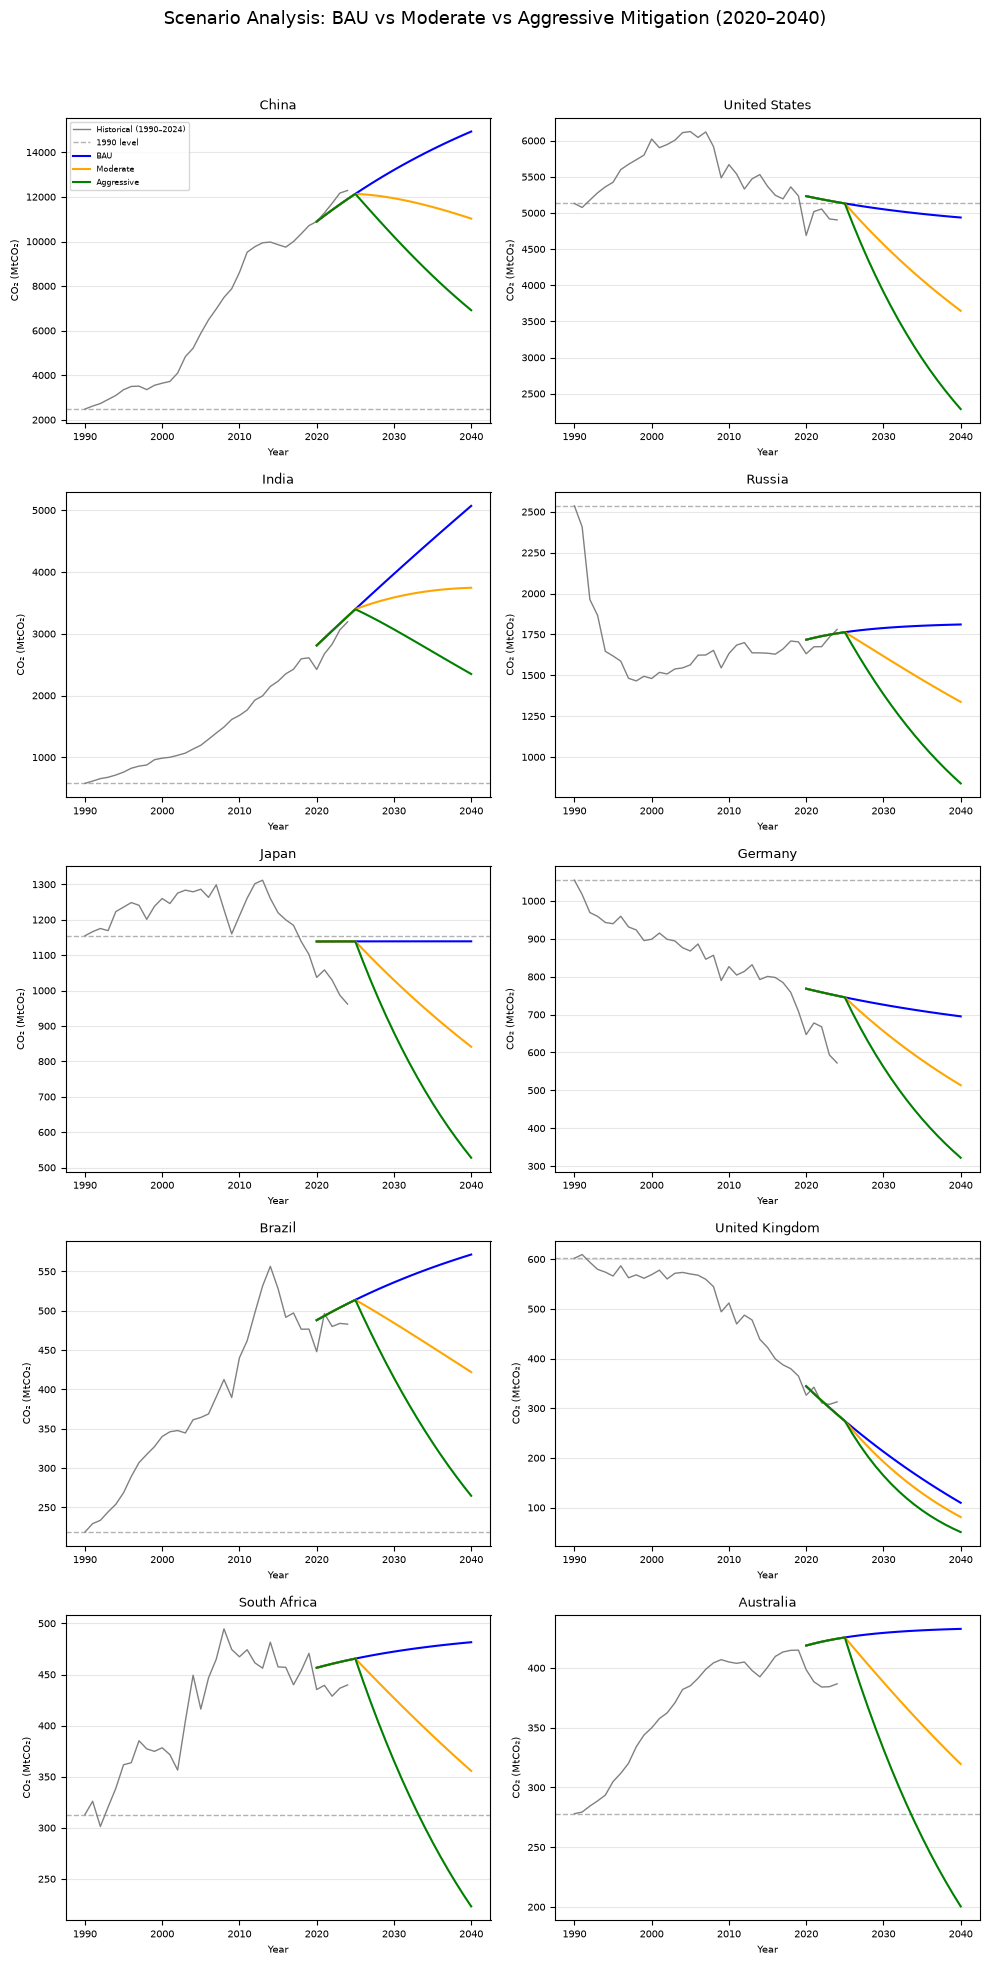

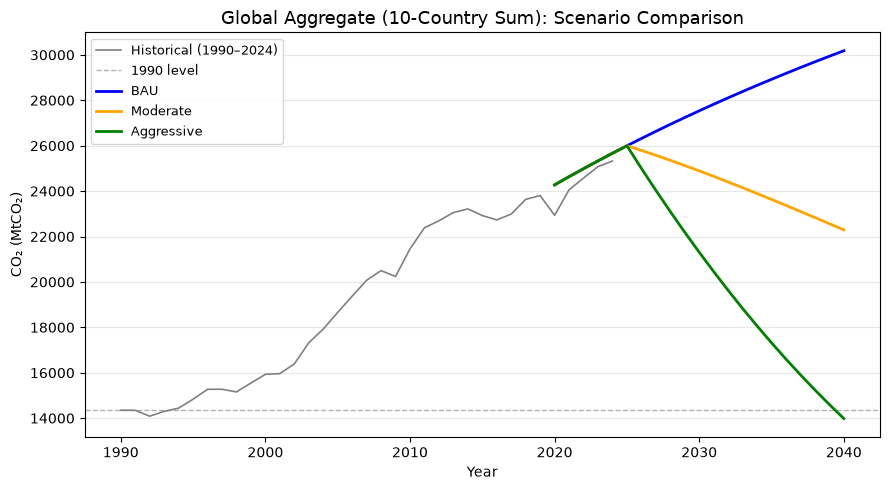

In [3]:
SCENARIO_COLORS = {'BAU': 'blue', 'Moderate': 'orange', 'Aggressive': 'green'}

# Per-country overlay charts
fig, axes = plt.subplots(5, 2, figsize=(10, 20))
axes_flat = axes.flatten()

for ax, country in zip(axes_flat, COUNTRIES):
    hist = (
        df_filtered[df_filtered['country'] == country]
        .sort_values('year').set_index('year')['co2']
    )
    hist_1990_2024 = hist.loc[1990:2024]
    level_1990 = hist.loc[1990]

    bau_2020_2040 = bau_series(country, 2020, 2040)

    ax.plot(hist_1990_2024.index, hist_1990_2024.values,
            color='grey', linewidth=1, label='Historical (1990–2024)')
    ax.axhline(y=level_1990, color='grey', linestyle='--', linewidth=1, alpha=0.6,
               label='1990 level')

    for scenario, color in SCENARIO_COLORS.items():
        if scenario == 'BAU':
            series = bau_2020_2040
        else:
            future = df_scenarios[
                (df_scenarios['country'] == country) &
                (df_scenarios['scenario'] == scenario)
            ].set_index('year')['co2_projected']
            series = pd.concat([bau_2020_2040.loc[2020:2024], future])
        ax.plot(series.index, series.values, color=color, linewidth=1.5, label=scenario)

    ax.set_title(country, fontsize=9)
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('CO₂ (MtCO₂)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(axis='y', alpha=0.3)

axes_flat[0].legend(fontsize=6, loc='upper left')
plt.suptitle('Scenario Analysis: BAU vs Moderate vs Aggressive Mitigation (2020–2040)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Global aggregate chart
hist_global = (
    df_filtered[df_filtered['country'].isin(COUNTRIES)]
    .groupby('year')['co2'].sum()
    .loc[1990:2024]
)
level_1990_global = hist_global.loc[1990]

bau_global_2020_2040 = pd.concat(
    [bau_series(c, 2020, 2040) for c in COUNTRIES], axis=1
).sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_global.index, hist_global.values, color='grey', linewidth=1.2,
        label='Historical (1990–2024)')
ax.axhline(y=level_1990_global, color='grey', linestyle='--', linewidth=1, alpha=0.6,
           label='1990 level')

for scenario, color in SCENARIO_COLORS.items():
    if scenario == 'BAU':
        series = bau_global_2020_2040
    else:
        future_global = (
            df_scenarios[df_scenarios['scenario'] == scenario]
            .groupby('year')['co2_projected'].sum()
        )
        series = pd.concat([bau_global_2020_2040.loc[2020:2024], future_global])
    ax.plot(series.index, series.values, color=color, linewidth=2, label=scenario)

ax.set_title('Global Aggregate (10-Country Sum): Scenario Comparison', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (MtCO₂)')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()


<a id='54-impact'></a>
### 5.4 Impact Summary

Compute cumulative CO₂ per country per scenario (2025–2040 sum). Plot as a grouped bar chart.


/var/folders/mg/c2kctt2d4b9b387hbm228yjc0000gn/T/ipykernel_43681/3942492173.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cumulative['Aggressive_pct_reduction'] = (


scenario,BAU,Moderate,Aggressive,Aggressive_pct_reduction
country,,,,
China,218085.2,187133.8,150368.0,31.1
United States,80392.2,69465.7,56419.0,29.8
India,67909.0,57954.2,46178.2,32.0
Russia,28697.9,24752.0,20046.6,30.1
Japan,18226.5,15731.8,12755.5,30.0
Germany,11498.8,9944.8,8087.9,29.7
Brazil,8716.3,7500.6,6053.5,30.5
United Kingdom,2999.0,2653.5,2231.8,25.6
South Africa,7593.7,6548.1,5301.5,30.2


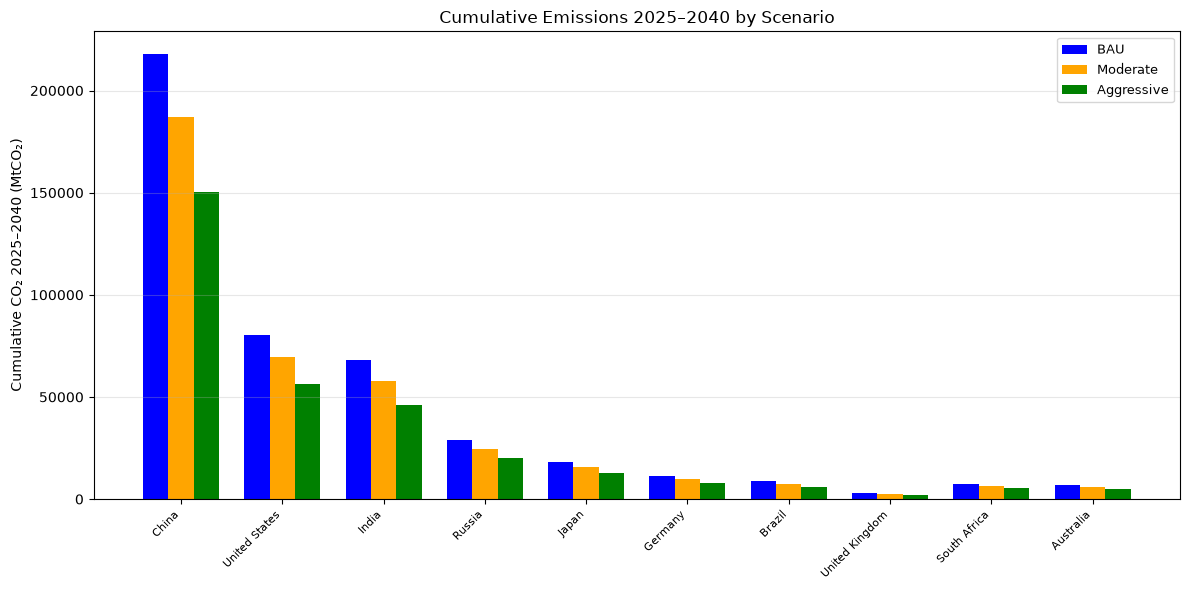

In [4]:
# Cumulative CO₂ 2025–2040 per country per scenario
df_cumulative = (
    df_scenarios.groupby(['country', 'scenario'])['co2_projected']
    .sum()
    .unstack('scenario')[['BAU', 'Moderate', 'Aggressive']]
    .loc[COUNTRIES]
)
df_cumulative['Aggressive_pct_reduction'] = (
    (df_cumulative['BAU'] - df_cumulative['Aggressive']) / df_cumulative['BAU'] * 100
)
display(df_cumulative.round(1))

# Grouped bar chart
x = np.arange(len(COUNTRIES))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (scenario, color) in enumerate(SCENARIO_COLORS.items()):
    ax.bar(x + (i - 1) * width, df_cumulative[scenario], width,
           label=scenario, color=color)

ax.set_xticks(x)
ax.set_xticklabels(COUNTRIES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Cumulative CO₂ 2025–2040 (MtCO₂)')
ax.set_title('Cumulative Emissions 2025–2040 by Scenario')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**✏️ Interpretation (3–5 sentences):** Which countries benefit most from aggressive mitigation in absolute and percentage terms?

**China** shows by far the largest absolute cumulative reduction under Aggressive mitigation — about 67,700 MtCO₂ saved versus BAU over 2025–2040 (a 31.1% cut), simply because its BAU trajectory is the largest and still-growing base in the panel, so a fixed −5%/year compounding rate removes far more total tonnage there than anywhere else. In percentage terms, **India** shows the largest relative reduction (32.0% vs BAU), narrowly ahead of China and the other high-growth-BAU countries, since the same compounding rate applied to a steeply rising baseline removes an increasing share of an ever-larger yearly total. **The United Kingdom shows the smallest percentage reduction (25.6%)** — a reminder that the mechanism is purely mechanical: a fixed % compounding rate on a *declining* BAU base compounds against smaller and smaller absolute yearly quantities, so the relative gap between BAU and Aggressive narrows faster than for countries with flat or growing BAU trajectories. This pattern — large emitters and high-growth economies show the biggest absolute *and* percentage gains from aggressive mitigation, while already-declining economies show comparatively modest relative gains — is a direct consequence of applying one uniform rate to different-shaped BAU curves, not evidence that aggressive mitigation matters less for countries like the UK. As emphasized in §5.1, these rankings reflect the illustrative flat-rate assumption applied here, not a measure of each country's actual differentiated mitigation potential or policy ambition.


<a id='55-sensitivity'></a>
### 5.5 Parameter Sensitivity *(Stretch Goal)*

For one country of your choice, show how cumulative 2025–2040 emissions change as the Moderate reduction rate varies from 1% to 4% in 1% steps.

| Reduction Rate | Cumulative CO₂ 2025–2040 (MtCO₂) | % Reduction vs BAU |
|---------------|----------------------------------|-------------------|
| 1% | | |
| 2% | | |
| 3% | | |
| 4% | | |


In [5]:
# Sensitivity table for one selected country
SENSITIVITY_COUNTRY = 'Brazil'

bau_country = bau_series(SENSITIVITY_COUNTRY, 2025, 2040)
years_elapsed = np.arange(len(bau_country))
bau_cumulative = bau_country.sum()

sensitivity_rows = []
for rate_pct in [1, 2, 3, 4]:
    rate = rate_pct / 100
    projected = bau_country.values * (1 - rate) ** years_elapsed
    cumulative = projected.sum()
    pct_reduction = (bau_cumulative - cumulative) / bau_cumulative * 100
    sensitivity_rows.append({
        'Reduction Rate':                  f'{rate_pct}%',
        'Cumulative CO2 2025-2040 (MtCO2)': round(float(cumulative), 1),
        '% Reduction vs BAU':               round(float(pct_reduction), 2),
    })

df_sensitivity = pd.DataFrame(sensitivity_rows)
print(f"Parameter sensitivity for {SENSITIVITY_COUNTRY} "
      f"(BAU cumulative 2025–2040: {bau_cumulative:,.1f} MtCO₂)")
display(df_sensitivity)


Parameter sensitivity for Brazil (BAU cumulative 2025–2040: 8,716.3 MtCO₂)


,Reduction Rate,Cumulative CO2 2025-2040 (MtCO2),% Reduction vs BAU
0,1%,8079.9,7.30
1,2%,7500.6,13.95
2,3%,6972.9,20.00
3,4%,6492.0,25.52


---
> ```
> git add notebook/week5_scenarios.ipynb data/scenario_projections.csv
> git commit -m "Week 5: scenario analysis complete"
> git push
> ```


---
<a id='week6'></a>
# Week 6 — Notebook Finalisation and Optional Streamlit Dashboard

**Learning Objective:** Finalise the notebook to professional standards; optionally build the dashboard.

### 6.1 Notebook Finalisation Checklist

- [ ] Every section has an **opening markdown** (what + why) and a **closing summary** (key findings)
- [ ] **Table of Contents** at the top links to all completed sections
- [ ] All charts: consistent colour schemes, font sizes, and labelling
- [ ] All debugging `print()` statements removed
- [ ] **Kernel → Restart & Run All** — zero errors top to bottom

### 6.2 Streamlit App *(Stretch Goal)*

Open `app.py` (already scaffolded in this repository) and fill in the `# TODO:` sections using Plotly Express charts and your generated data files.

> **Prerequisite:** `data/ghg_features.csv` must exist. The app gracefully handles missing files.

```bash
streamlit run app.py
```

**Minimum interactivity required:**
- `st.selectbox` for country selection
- `st.multiselect` for gas type
- `st.radio` for scenario selection (if Week 5 complete)
- All charts: **Plotly Express** (not Matplotlib)

### 6.3 GitHub Repository Requirements

- [ ] `notebook/week1_eda.ipynb` … `notebook/week5_scenarios.ipynb` — all cells run cleanly
- [ ] `app.py` — runs without errors
- [ ] `data/ghg_features.csv` and (if applicable) `data/scenario_projections.csv`
- [ ] `requirements.txt` — complete
- [ ] `README.md` — team names filled in, instructions verified

---
> ```
> git add .
> git commit -m "Week 6: notebook finalised, Streamlit app added"
> git push
> ```


---
<a id='week7'></a>
# Week 7 — Final Presentation

**Learning Objective:** Deliver a structured 1-hour presentation demonstrating the full analytical workflow.

> *The project report template and formal submission requirements will be provided by the course administration separately.*

### Presentation Outline (60 minutes)

| Slot | Duration | Content |
|------|----------|---------|
| Introduction | 5 min | Project objective, team intro, dataset overview |
| EDA Findings | 10 min | 3 charts + written observations |
| Feature Engineering | 5 min | Key features, rolling mean and lag rationale |
| Model Comparison | 15 min | Live notebook — Baseline → LR → RF → ETS(A,Ad,N), consolidated table |
| Forecasts | 10 min | 3 country forecast plots, summary table, trend interpretation |
| Scenario Analysis | 5 min | Key finding *(if completed)* |
| Streamlit Demo | 5 min | Live app run *(if completed)* |
| Key Takeaways & Q&A | 5 min | Limitations, learnings, next steps |

### Final Submission Checklist

- [ ] Jupyter Notebook: fully documented, all cells run top to bottom without errors
- [ ] Streamlit app *(if built)*: runs without errors, `requirements.txt` complete
- [ ] GitHub repository link **shared with mentor before the session**
- [ ] Presentation slides **shared with mentor before the session**
- [ ] Project report: submitted in IDEAS TIH template format *(template from course admin)*